# Hyperparameter Search Analysis
Local analysis of WeightedMSELoss penalty λ search results from v1 (λ∈{5–15}) and v2 (λ∈{15–30}).

**Note:** MSE/RMSE columns are only present in CSVs generated after the search loop was updated. Older CSVs skip those plots automatically.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

df1 = pd.read_csv('hyperparameter_search_results.csv').dropna(subset=['lam'])
df2 = pd.read_csv('hyperparameter_search_results_v2.csv').dropna(subset=['lam'])
df1['search'] = 'v1 (λ=5–15)'
df2['search'] = 'v2 (λ=15–30)'

df = pd.concat([df1, df2], ignore_index=True)
df['lam'] = df['lam'].astype(int)

HAS_MSE = 'global_mse' in df.columns
print(f'Total runs: {len(df)}  (v1={len(df1)}, v2={len(df2)})')
print(f'MSE/RMSE columns available: {HAS_MSE}')

lam_vals = sorted(df['lam'].unique())
colors   = cm.tab10(np.linspace(0, 0.8, len(lam_vals)))
cmap     = {lam: c for lam, c in zip(lam_vals, colors)}

Total runs: 60  (v1=30, v2=30)
MSE/RMSE columns available: False


## Figure 1 — Global R² per λ

Saved hpsearch_fig1_r2.png


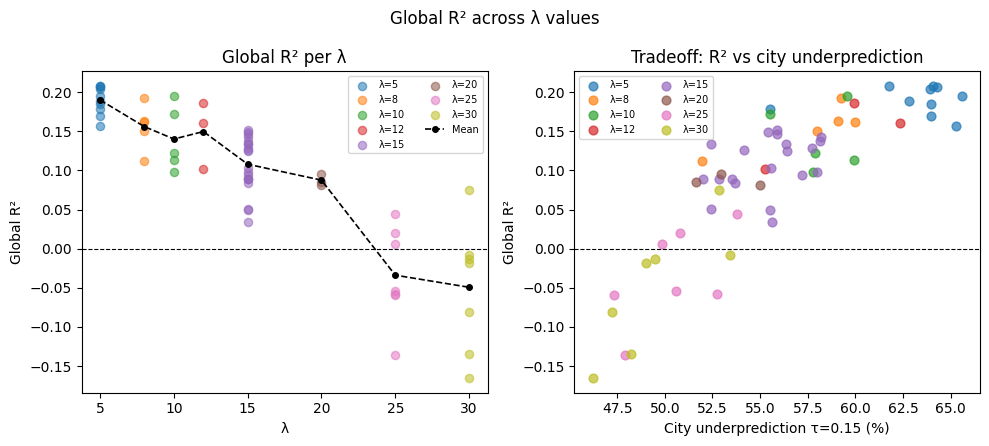

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Global R² across λ values', fontsize=12)

# Left: R² scatter per λ
ax = axes[0]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['global_r2'], alpha=0.55, color=cmap[lam], s=35, label=f'λ={lam}')
mean_r2 = df.groupby('lam')['global_r2'].mean()
ax.plot(mean_r2.index, mean_r2.values, 'k--o', lw=1.2, ms=4, label='Mean')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('λ'); ax.set_ylabel('Global R²')
ax.set_title('Global R² per λ')
ax.legend(fontsize=7, ncol=2)

# Right: R² vs city underprediction tradeoff
ax = axes[1]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter(sub['city15_underprediction'], sub['global_r2'],
               alpha=0.7, color=cmap[lam], s=40, label=f'λ={lam}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('City underprediction τ=0.15 (%)')
ax.set_ylabel('Global R²')
ax.set_title('Tradeoff: R² vs city underprediction')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('hpsearch_fig1_r2.png', dpi=150, bbox_inches='tight')
print('Saved hpsearch_fig1_r2.png')
plt.show()

## Figure 2 — City underprediction: τ=0.15 vs τ=0.20

Saved hpsearch_fig2_underpred.png


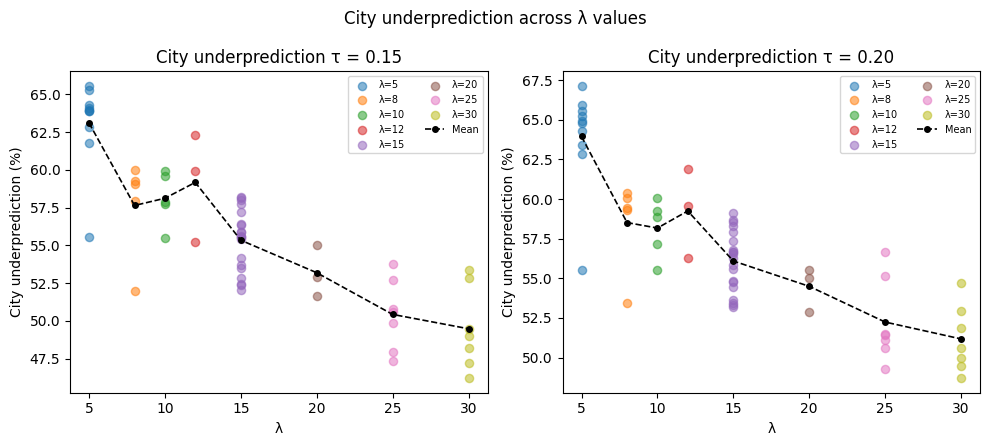

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('City underprediction across λ values', fontsize=12)

for ax, (col, label) in zip(axes, [
    ('city15_underprediction', 'τ = 0.15'),
    ('city_underprediction',   'τ = 0.20'),
]):
    for lam in lam_vals:
        sub = df[df['lam'] == lam]
        ax.scatter([lam]*len(sub), sub[col], alpha=0.55, color=cmap[lam], s=35, label=f'λ={lam}')
    mean_vals = df.groupby('lam')[col].mean()
    ax.plot(mean_vals.index, mean_vals.values, 'k--o', lw=1.2, ms=4, label='Mean')
    ax.set_xlabel('λ'); ax.set_ylabel('City underprediction (%)')
    ax.set_title(f'City underprediction {label}')
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('hpsearch_fig2_underpred.png', dpi=150, bbox_inches='tight')
print('Saved hpsearch_fig2_underpred.png')
plt.show()

## Figure 3 — Global R² vs city R²

Saved hpsearch_fig3_r2_comparison.png


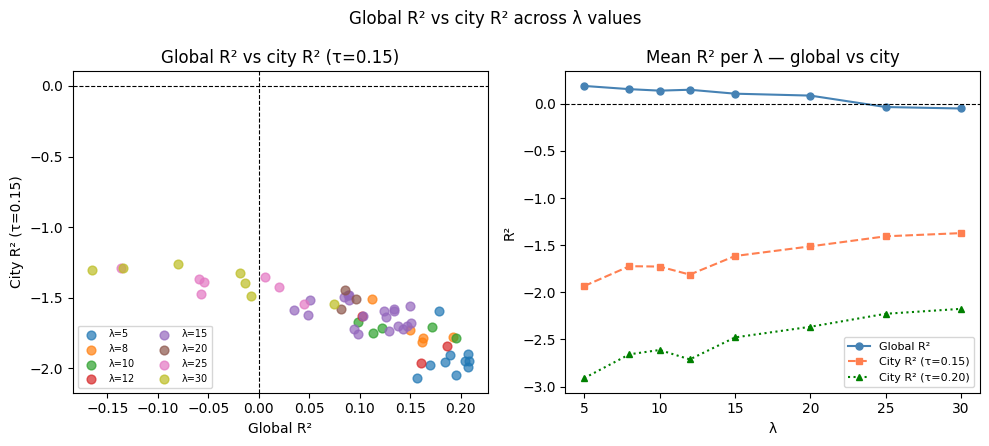

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Global R² vs city R² across λ values', fontsize=12)

# Left: Global R² vs city R² (τ=0.15) scatter, coloured by λ
ax = axes[0]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter(sub['global_r2'], sub['city15_r2'],
               alpha=0.7, color=cmap[lam], s=40, label=f'λ={lam}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Global R²')
ax.set_ylabel('City R² (τ=0.15)')
ax.set_title('Global R² vs city R² (τ=0.15)')
ax.legend(fontsize=7, ncol=2)

# Right: mean Global R² vs mean city R² per λ (line plot showing the tradeoff)
ax = axes[1]
mean_global = df.groupby('lam')['global_r2'].mean()
mean_city15 = df.groupby('lam')['city15_r2'].mean()
mean_city20 = df.groupby('lam')['city_r2'].mean()
ax.plot(mean_global.index, mean_global.values, 'o-', color='steelblue', lw=1.5, ms=5, label='Global R²')
ax.plot(mean_city15.index, mean_city15.values, 's--', color='coral', lw=1.5, ms=5, label='City R² (τ=0.15)')
ax.plot(mean_city20.index, mean_city20.values, '^:', color='green', lw=1.5, ms=5, label='City R² (τ=0.20)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('λ')
ax.set_ylabel('R²')
ax.set_title('Mean R² per λ — global vs city')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('hpsearch_fig3_r2_comparison.png', dpi=150, bbox_inches='tight')
print('Saved hpsearch_fig3_r2_comparison.png')
plt.show()

## Figure 4 — Max prediction and mean summary

Saved hpsearch_fig4_summary.png


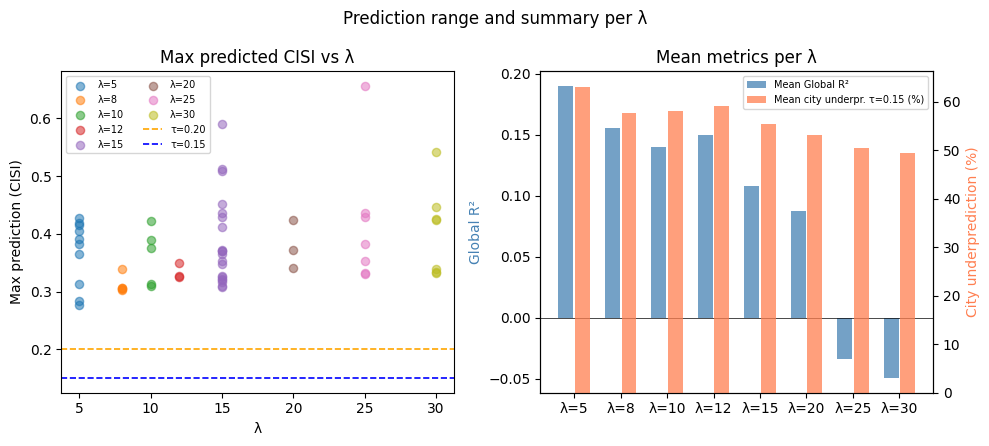

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Prediction range and summary per λ', fontsize=12)

# Left: pred_max vs λ
ax = axes[0]
for lam in lam_vals:
    sub = df[df['lam'] == lam]
    ax.scatter([lam]*len(sub), sub['pred_max'], alpha=0.55, color=cmap[lam], s=35, label=f'λ={lam}')
ax.axhline(0.20, color='orange', lw=1.2, ls='--', label='τ=0.20')
ax.axhline(0.15, color='blue',   lw=1.2, ls='--', label='τ=0.15')
ax.set_xlabel('λ'); ax.set_ylabel('Max prediction (CISI)')
ax.set_title('Max predicted CISI vs λ')
ax.legend(fontsize=7, ncol=2)

# Right: mean R² and mean city15 underprediction per λ (dual axis bar)
ax = axes[1]
mean_df = df.groupby('lam')[['global_r2', 'city15_underprediction']].mean()
x = np.arange(len(mean_df))
ax2 = ax.twinx()
ax.bar(x - 0.18, mean_df['global_r2'], 0.32, label='Mean Global R²', color='steelblue', alpha=0.75)
ax2.bar(x + 0.18, mean_df['city15_underprediction'], 0.32,
        label='Mean city underpr. τ=0.15 (%)', color='coral', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels([f'λ={l}' for l in mean_df.index])
ax.set_ylabel('Global R²', color='steelblue')
ax2.set_ylabel('City underprediction (%)', color='coral')
ax.set_title('Mean metrics per λ')
ax.axhline(0, color='k', lw=0.5)
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=7)

plt.tight_layout()
plt.savefig('hpsearch_fig4_summary.png', dpi=150, bbox_inches='tight')
print('Saved hpsearch_fig4_summary.png')
plt.show()

## Best runs and final config

In [34]:
best_per_lam = df.loc[df.groupby('lam')['global_r2'].idxmax()].sort_values('lam')
show_cols = ['lam','lr','dropout','global_r2','global_mae','city15_underprediction','city_underprediction','pred_max']
print('Best run per λ (by global R²):')
print(best_per_lam[show_cols].to_string(index=False))

Best run per λ (by global R²):
 lam       lr  dropout  global_r2  global_mae  city15_underprediction  city_underprediction  pred_max
   5 0.000870      0.1   0.207898    0.023168               64.089990             65.532150  0.364948
   8 0.000728      0.2   0.192289    0.023591               59.258495             59.409435  0.339227
  10 0.000240      0.2   0.195458    0.024516               59.565690             59.228410  0.389114
  12 0.000442      0.3   0.186176    0.024718               59.922565             59.532692  0.325740
  15 0.000972      0.3   0.151243    0.026393               55.862617             56.772762  0.326046
  20 0.000186      0.3   0.095981    0.028142               52.928490             55.549137  0.341255
  25 0.000145      0.3   0.044672    0.029200               53.791046             56.655080  0.352886
  30 0.000808      0.3   0.074494    0.028237               52.837296             52.964188  0.332502


In [35]:
r2_min, r2_max = df['global_r2'].min(), df['global_r2'].max()
uc_min, uc_max = df['city15_underprediction'].min(), df['city15_underprediction'].max()
df['r2_norm'] = (df['global_r2'] - r2_min) / (r2_max - r2_min)
df['uc_norm'] = 1 - (df['city15_underprediction'] - uc_min) / (uc_max - uc_min)
df['score']   = 0.5 * df['r2_norm'] + 0.5 * df['uc_norm']

top10 = df.nlargest(10, 'score')[show_cols + ['score','search']]
print('Top 10 runs (balanced score: 50% R², 50% city underprediction τ=0.15):')
print(top10.to_string(index=False))

Top 10 runs (balanced score: 50% R², 50% city underprediction τ=0.15):
 lam       lr  dropout  global_r2  global_mae  city15_underprediction  city_underprediction  pred_max    score       search
  15 0.000897      0.2   0.134045    0.025193               52.406097             53.433155  0.365277 0.741047  v1 (λ=5–15)
   8 0.000922      0.3   0.112388    0.026701               51.953410             53.461693  0.305727 0.723739  v1 (λ=5–15)
   5 0.000123      0.2   0.178134    0.023002               55.538822             55.524086  0.418529 0.719147  v1 (λ=5–15)
  10 0.000863      0.3   0.171967    0.024260               55.508095             55.555992  0.308998 0.711682  v1 (λ=5–15)
  20 0.000617      0.2   0.085417    0.027516               51.649803             52.893925  0.371295 0.695463 v2 (λ=15–30)
  15 0.000478      0.2   0.088448    0.027609               52.018760             53.339100  0.352931 0.689989  v1 (λ=5–15)
  15 0.000144      0.1   0.126259    0.024950               5

In [36]:
best = df.loc[df['score'].idxmax()]
print('=== BEST CONFIG (balanced) ===')
print(f"  λ (lam):              {int(best['lam'])}")
print(f"  lr:                   {best['lr']:.8f}")
print(f"  dropout:              {best['dropout']}")
print(f"  Global R²:            {best['global_r2']:.4f}")
print(f"  Global MAE:           {best['global_mae']:.4f}")
print(f"  City underpr. τ=0.15: {best['city15_underprediction']:.1f}%")
print(f"  City underpr. τ=0.20: {best['city_underprediction']:.1f}%")
print(f"  pred_max:             {best['pred_max']:.4f}")
print()
print('Paste into final train cell:')
print(f"  lam     = {int(best['lam'])}")
print(f"  lr      = {best['lr']:.8f}")
print(f"  dropout = {best['dropout']}")

=== BEST CONFIG (balanced) ===
  λ (lam):              15
  lr:                   0.00089691
  dropout:              0.2
  Global R²:            0.1340
  Global MAE:           0.0252
  City underpr. τ=0.15: 52.4%
  City underpr. τ=0.20: 53.4%
  pred_max:             0.3653

Paste into final train cell:
  lam     = 15
  lr      = 0.00089691
  dropout = 0.2


## Summary table per λ

In [37]:
summary = df.groupby('lam').agg(
    n=('lam', 'count'),
    mean_global_r2=('global_r2', 'mean'),
    best_global_r2=('global_r2', 'max'),
    mean_global_mae=('global_mae', 'mean'),
    mean_city15_underp=('city15_underprediction', 'mean'),
    best_city15_underp=('city15_underprediction', 'min'),
    mean_pred_max=('pred_max', 'mean'),
).round(5)
print(summary.to_string())

      n  mean_global_r2  best_global_r2  mean_global_mae  mean_city15_underp  best_city15_underp  mean_pred_max
lam                                                                                                            
5    10         0.18994         0.20790          0.02320            63.11450            55.53882        0.36782
8     5         0.15590         0.19229          0.02494            57.64571            51.95341        0.31188
10    5         0.14006         0.19546          0.02556            58.12380            55.50810        0.36162
12    3         0.14961         0.18618          0.02479            59.17342            55.25777        0.33381
15   20         0.10788         0.15124          0.02650            55.34582            52.01876        0.38725
20    3         0.08752         0.09598          0.02748            53.19224            51.64980        0.37908
25    7        -0.03390         0.04467          0.03048            50.43152            47.33860        